# Language Identification for Indian Languages using IndicCorp v2

This notebook builds an end-to-end **language identification (LID)** system for 23 Indian
language/script combinations using the [IndicCorp v2](https://huggingface.co/datasets/ai4bharat/IndicCorpV2)
corpus.

**Pipeline**

1. Dynamically discover the language/script configs exposed by `ai4bharat/IndicCorpV2`.
2. Stream documents per language, split paragraphs into sentences, and keep 1000 valid
   sentences per language.
3. Perform a stratified 80/10/10 train/validation/test split (same number of samples per
   language in each split).
4. Represent sentences with a **from-scratch TF-IDF vectorizer** combining:
   - Word unigrams and bigrams
   - Character 2-grams, 3-grams and 4-grams
5. Train a **from-scratch multinomial (softmax) logistic regression** classifier via
   mini-batch gradient descent.
6. Evaluate with a **from-scratch macro-F1** implementation (and accuracy, confusion matrix).

> **No `sklearn` classes are used anywhere** for vectorization, modeling, or evaluation.
> `scipy.sparse` is used only as an efficient container/algebra library for the TF-IDF
> matrix (comparable to using `numpy` arrays) — all the actual TF-IDF and logistic
> regression *logic* is implemented by hand below.

> **Note on data access:** `ai4bharat/IndicCorpV2` is a large corpus. This notebook streams
> data instead of downloading everything. If you get an authentication error, run
> `huggingface-cli login` (or accept the dataset's terms of use on the Hub) before
> executing the data-collection cells.


In [2]:
!pip install -q datasets huggingface_hub scipy numpy pandas matplotlib tqdm


In [23]:
import re
import json
import random
import pickle
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.auto import tqdm

from datasets import load_dataset, get_dataset_config_names

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## Step 1: Discover available language/script configs in IndicCorp v2

IndicCorp v2 covers 23 language-script combinations, but on the Hub these can be exposed
either as (a) one **config** per language with a `train` split, or (b) a single default
config with one **split** per language-script code (e.g. `asm_Beng`, `hin_Deva`,
`urd_Arab`, ..., plus a couple without a script suffix like `khasi`, `santhali`). This
repo currently uses pattern (b). We detect the pattern automatically from the Hub instead
of hard-coding it, so the notebook keeps working if the repo structure changes.


In [24]:
from datasets import get_dataset_split_names

DATASET_NAME = "ai4bharat/IndicCorpV2"

all_configs = get_dataset_config_names(DATASET_NAME)
print(f"Found {len(all_configs)} configs:")
print(all_configs)


Found 1 configs:
['indiccorp_v2']


In [25]:
# Normalise to a flat list of (config_name, split_name) pairs to load, and a
# human-readable language label (used as the classification target).
#
# - If there's a single config exposing many splits, each split IS a language
#   (this is the current IndicCorpV2 layout: config="default", splits=
#   ["asm_Beng", "ben_Beng", ..., "khasi", "santhali"]).
# - If there are many configs each exposing a "train" split, each config IS a
#   language (the layout originally assumed).

lang_targets = []  # list of (config_name, split_name, language_label)

if len(all_configs) == 1:
    config_name = all_configs[0]
    splits = get_dataset_split_names(DATASET_NAME, config_name)
    for s in splits:
        lang_targets.append((config_name, s, s))
else:
    for c in all_configs:
        splits = get_dataset_split_names(DATASET_NAME, c)
        target_split = "train" if "train" in splits else splits[0]
        lang_targets.append((c, target_split, c))

lang_targets = sorted(lang_targets, key=lambda t: t[2])

# The assignment asks for 23 languages/scripts; keep at most 23 for a
# reproducible run (edit this list by hand if you want a specific subset).
lang_targets = lang_targets[:23]

print(f"Using {len(lang_targets)} language targets (config, split, label):")
for i, t in enumerate(lang_targets):
    print(i, t)


Using 23 language targets (config, split, label):
0 ('indiccorp_v2', 'asm_Beng', 'asm_Beng')
1 ('indiccorp_v2', 'ben_Beng', 'ben_Beng')
2 ('indiccorp_v2', 'brx_Deva', 'brx_Deva')
3 ('indiccorp_v2', 'doi_Deva', 'doi_Deva')
4 ('indiccorp_v2', 'gom_Deva', 'gom_Deva')
5 ('indiccorp_v2', 'guj_Gujr', 'guj_Gujr')
6 ('indiccorp_v2', 'hin_Deva', 'hin_Deva')
7 ('indiccorp_v2', 'kan_Knda', 'kan_Knda')
8 ('indiccorp_v2', 'kas_Arab', 'kas_Arab')
9 ('indiccorp_v2', 'khasi', 'khasi')
10 ('indiccorp_v2', 'mai_Deva', 'mai_Deva')
11 ('indiccorp_v2', 'mal_Mlym', 'mal_Mlym')
12 ('indiccorp_v2', 'mar_Deva', 'mar_Deva')
13 ('indiccorp_v2', 'mni_Mtei', 'mni_Mtei')
14 ('indiccorp_v2', 'npi_Deva', 'npi_Deva')
15 ('indiccorp_v2', 'ory_Orya', 'ory_Orya')
16 ('indiccorp_v2', 'pan_Guru', 'pan_Guru')
17 ('indiccorp_v2', 'san_Deva', 'san_Deva')
18 ('indiccorp_v2', 'santhali', 'santhali')
19 ('indiccorp_v2', 'snd_Deva', 'snd_Deva')
20 ('indiccorp_v2', 'tam_Taml', 'tam_Taml')
21 ('indiccorp_v2', 'tel_Telu', 'tel_Telu'

## Step 2: Sentence tokenizer

Each IndicCorp record is a *paragraph*, not a sentence. Since a single trained sentence
tokenizer doesn't exist for every Indic script, we use a lightweight, script-agnostic
splitter based on sentence-final punctuation used across Indian scripts (the Devanagari
danda `।`/`॥`, Urdu `۔`/`؟`, and the regular Latin `.`/`!`/`?`), plus newlines.


In [26]:
SENTENCE_BOUNDARY_RE = re.compile(
    r'(?<=[।॥.!?۔؟\u0965\u0964])\s+|\n+'
)

def split_into_sentences(paragraph: str):
    '''A lightweight, script-agnostic sentence splitter.'''
    if not isinstance(paragraph, str) or not paragraph.strip():
        return []
    paragraph = re.sub(r'\s+', ' ', paragraph.strip())
    pieces = SENTENCE_BOUNDARY_RE.split(paragraph)
    sentences = [p.strip() for p in pieces if p and p.strip()]
    return sentences


def is_valid_sentence(sent: str, min_words=4, max_words=60):
    n_words = len(sent.split())
    return min_words <= n_words <= max_words


## Step 3: Collect 1000 sentences per language via streaming

We stream documents (so we never download the full corpus), sentence-split each
paragraph, and keep de-duplicated sentences that pass a simple length filter until we
reach 1000 per language.


In [27]:
def collect_sentences_for_config(config_name, split_name, target_count=random.randint(1000, 2000),
                                  min_words=4, max_words=60,
                                  max_docs_to_scan=200_000):
    '''Stream one (config, split) pair and harvest sentences from it.'''
    ds = load_dataset(DATASET_NAME, name=config_name, split=split_name, streaming=True)

    collected = []
    seen = set()
    scanned = 0

    for example in ds:
        scanned += 1
        text = example.get("text", "")
        for sent in split_into_sentences(text):
            if is_valid_sentence(sent, min_words, max_words) and sent not in seen:
                seen.add(sent)
                collected.append(sent)
                if len(collected) >= target_count:
                    return collected
        if scanned >= max_docs_to_scan:
            break

    return collected


In [28]:
TARGET_PER_LANGUAGE = random.randint(1000, 2000)

all_rows = []
for config_name, split_name, language_label in tqdm(lang_targets, desc="Languages"):
    sentences = collect_sentences_for_config(config_name, split_name, TARGET_PER_LANGUAGE)
    print(f"{language_label}: collected {len(sentences)} sentences")
    if len(sentences) < TARGET_PER_LANGUAGE:
        print(f"  WARNING: only found {len(sentences)} valid sentences for "
              f"'{language_label}'. Consider relaxing min/max word filters or "
              f"raising max_docs_to_scan for this language.")
    for s in sentences[:TARGET_PER_LANGUAGE]:
        all_rows.append({"text": s, "language": language_label})

df = pd.DataFrame(all_rows)
print(df.shape)
df.head()


Languages:   0%|          | 0/23 [00:00<?, ?it/s]

asm_Beng: collected 1114 sentences
ben_Beng: collected 1114 sentences
brx_Deva: collected 1114 sentences
doi_Deva: collected 1114 sentences
gom_Deva: collected 1114 sentences
guj_Gujr: collected 1114 sentences
hin_Deva: collected 1114 sentences
kan_Knda: collected 1114 sentences
kas_Arab: collected 1114 sentences
khasi: collected 1114 sentences
mai_Deva: collected 1114 sentences
mal_Mlym: collected 1114 sentences
mar_Deva: collected 1114 sentences
mni_Mtei: collected 1114 sentences
npi_Deva: collected 1114 sentences
ory_Orya: collected 1114 sentences
pan_Guru: collected 1114 sentences
san_Deva: collected 1114 sentences
santhali: collected 1114 sentences
snd_Deva: collected 1114 sentences
tam_Taml: collected 1114 sentences
tel_Telu: collected 1114 sentences
urd_Arab: collected 1114 sentences
(25622, 2)


,text,language
0,ঘটনাৰ বিৱৰণি মতে বোকাকাতৰ কৈলাখাতত নিয়মিতভাৱে ...,asm_Beng
1,বোকাখাতৰ কৈলাখাতত নিয়মিতভাৱে বহা এই জুৱাৰ থলীত...,asm_Beng
2,ৰাণু মণ্ডলৰ সুৱদী কন্ঠত মুগ্ধ হৈ ভাইজান ছলমানে...,asm_Beng
3,"বহুতে ইয়াকো কৈছে যে, ছলমানৰ আহিবলগীয়া ছবিৰ বাব...",asm_Beng
4,কিন্তু আঁচল কথাতো হল ছচিয়েল মিডিয়াত প্ৰচাৰিত এ...,asm_Beng


In [29]:
languages_sorted = sorted(df["language"].unique())
lang2id = {lang: i for i, lang in enumerate(languages_sorted)}
id2lang = {i: lang for lang, i in lang2id.items()}

df["label"] = df["language"].map(lang2id)
df.to_csv("indiccorp_lid_full.csv", index=False)

with open("label_map.json", "w", encoding="utf-8") as f:
    json.dump(id2lang, f, ensure_ascii=False, indent=2)

df["language"].value_counts()


language
asm_Beng    1114
mar_Deva    1114
tel_Telu    1114
tam_Taml    1114
snd_Deva    1114
santhali    1114
san_Deva    1114
pan_Guru    1114
ory_Orya    1114
npi_Deva    1114
mni_Mtei    1114
mal_Mlym    1114
ben_Beng    1114
mai_Deva    1114
khasi       1114
kas_Arab    1114
kan_Knda    1114
hin_Deva    1114
guj_Gujr    1114
gom_Deva    1114
doi_Deva    1114
brx_Deva    1114
urd_Arab    1114
Name: count, dtype: int64

## Step 4: Stratified 80/10/10 split

We split *within each language* so every split has the same number of samples per
language (stratified sampling), then shuffle each split.


In [30]:
def stratified_split(df, label_col="language", ratios=(0.8, 0.1, 0.1), seed=RANDOM_SEED):
    assert abs(sum(ratios) - 1.0) < 1e-6
    rng = np.random.RandomState(seed)
    train_parts, val_parts, test_parts = [], [], []

    for lang, group in df.groupby(label_col):
        idx = group.index.to_numpy().copy()
        rng.shuffle(idx)
        n = len(idx)
        n_train = int(round(ratios[0] * n))
        n_val = int(round(ratios[1] * n))
        train_idx = idx[:n_train]
        val_idx = idx[n_train:n_train + n_val]
        test_idx = idx[n_train + n_val:]

        train_parts.append(group.loc[train_idx])
        val_parts.append(group.loc[val_idx])
        test_parts.append(group.loc[test_idx])

    train_df = pd.concat(train_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    val_df = pd.concat(val_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    test_df = pd.concat(test_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return train_df, val_df, test_df


train_df, val_df, test_df = stratified_split(df)
print("Train:", train_df.shape, " Val:", val_df.shape, " Test:", test_df.shape)
print(train_df["language"].value_counts())

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)


Train: (20493, 3)  Val: (2553, 3)  Test: (2576, 3)
language
tam_Taml    891
hin_Deva    891
mai_Deva    891
snd_Deva    891
mar_Deva    891
khasi       891
kas_Arab    891
gom_Deva    891
urd_Arab    891
ory_Orya    891
mal_Mlym    891
santhali    891
pan_Guru    891
guj_Gujr    891
kan_Knda    891
doi_Deva    891
san_Deva    891
npi_Deva    891
mni_Mtei    891
ben_Beng    891
brx_Deva    891
tel_Telu    891
asm_Beng    891
Name: count, dtype: int64


## Step 5: Custom TF-IDF Vectorizer (word + character n-grams)

Design:

- **Word n-grams**: tokens found with a Unicode-aware `\w+` regex (works across scripts),
  combined into unigrams (`W1_...`) and bigrams (`W2_..._...`).
- **Character n-grams**: 2/3/4-grams computed **per word**, with `#` boundary padding
  (fastText-style, e.g. `#word#`) so n-grams don't leak across word boundaries. Prefixed
  as `C2_`, `C3_`, `C4_`.
- **Vocabulary pruning**: `min_df` drops rare terms, `max_features` caps vocabulary size
  by keeping the most frequent remaining terms (mirrors `sklearn`'s behaviour, but is
  implemented manually).
- **IDF**: smoothed idf, `idf(t) = ln((1+N)/(1+df(t))) + 1`.
- **Normalization**: each row (document) vector is L2-normalized.

The design matrix is stored as a `scipy.sparse.csr_matrix` purely for memory/performance
reasons (dense would need ~tens of GB for this vocabulary size); no `sklearn` vectorizer
class is used.


In [31]:
TOKEN_RE = re.compile(r"\w+", re.UNICODE)

class CustomTfidfVectorizer:
    '''From-scratch TF-IDF vectorizer combining word (1,2)-grams and
    character (2,3,4)-grams. No sklearn classes are used anywhere.
    '''

    def __init__(self, word_ngram_range=(1, 2), char_ngram_sizes=(2, 3, 4),
                 min_df=2, max_features=60000, lowercase=True):
        self.word_ngram_range = word_ngram_range
        self.char_ngram_sizes = char_ngram_sizes
        self.min_df = min_df
        self.max_features = max_features
        self.lowercase = lowercase

        self.vocabulary_ = {}     # feature string -> column index
        self.idf_ = None          # np.array, len(vocabulary_)

    # ---------- feature extraction ----------
    def _preprocess(self, text):
        return text.lower() if self.lowercase else text

    def _word_tokens(self, text):
        return TOKEN_RE.findall(text)

    def _word_ngrams(self, tokens):
        feats = []
        lo, hi = self.word_ngram_range
        for n in range(lo, hi + 1):
            if n == 1:
                feats.extend(f"W1_{t}" for t in tokens)
            else:
                for i in range(len(tokens) - n + 1):
                    feats.append(f"W{n}_" + "_".join(tokens[i:i + n]))
        return feats

    def _char_ngrams(self, text):
        feats = []
        for word in text.split():
            padded = f"#{word}#"
            for n in self.char_ngram_sizes:
                if len(padded) < n:
                    continue
                for i in range(len(padded) - n + 1):
                    feats.append(f"C{n}_" + padded[i:i + n])
        return feats

    def _extract_features(self, raw_text):
        text = self._preprocess(raw_text)
        tokens = self._word_tokens(text)
        feats = self._word_ngrams(tokens)
        feats.extend(self._char_ngrams(text))
        return feats

    # ---------- vocabulary / idf ----------
    def fit(self, corpus):
        doc_freq = Counter()
        term_freq_total = Counter()
        n_docs = len(corpus)

        tokenized_docs = []
        for doc in corpus:
            feats = self._extract_features(doc)
            tokenized_docs.append(feats)
            for f in set(feats):
                doc_freq[f] += 1
            term_freq_total.update(feats)

        candidate_terms = [t for t, df_ in doc_freq.items() if df_ >= self.min_df]

        if self.max_features is not None and len(candidate_terms) > self.max_features:
            candidate_terms = sorted(
                candidate_terms, key=lambda t: term_freq_total[t], reverse=True
            )[: self.max_features]

        candidate_terms = sorted(candidate_terms)  # deterministic column order
        self.vocabulary_ = {t: i for i, t in enumerate(candidate_terms)}

        df_array = np.array([doc_freq[t] for t in candidate_terms], dtype=np.float64)
        self.idf_ = np.log((1.0 + n_docs) / (1.0 + df_array)) + 1.0

        return self, tokenized_docs

    def _docs_to_sparse(self, tokenized_docs):
        n_docs = len(tokenized_docs)
        n_feats = len(self.vocabulary_)

        rows, cols, data = [], [], []
        for r, feats in enumerate(tokenized_docs):
            counts = Counter(feats)
            for f, c in counts.items():
                col = self.vocabulary_.get(f)
                if col is not None:
                    rows.append(r)
                    cols.append(col)
                    data.append(c)

        tf = sp.csr_matrix((data, (rows, cols)), shape=(n_docs, n_feats), dtype=np.float64)
        tfidf = sp.csr_matrix(tf.multiply(self.idf_))

        norms = np.sqrt(tfidf.multiply(tfidf).sum(axis=1)).A1
        norms[norms == 0] = 1.0
        inv_norms = sp.diags(1.0 / norms)
        tfidf = sp.csr_matrix(inv_norms.dot(tfidf))
        return tfidf

    def fit_transform(self, corpus):
        _, tokenized_docs = self.fit(corpus)
        return self._docs_to_sparse(tokenized_docs)

    def transform(self, corpus):
        tokenized_docs = [self._extract_features(doc) for doc in corpus]
        return self._docs_to_sparse(tokenized_docs)


## Step 6: Fit the vectorizer on the training split only

The vocabulary and IDF weights are learned **only** from `train_df`, then applied to
validation/test (standard practice to avoid leakage).


In [32]:
vectorizer = CustomTfidfVectorizer(
    word_ngram_range=(1, 2),
    char_ngram_sizes=(2, 3, 4),
    min_df=2,
    max_features=60000,
)

X_train = vectorizer.fit_transform(train_df["text"].tolist())
X_val = vectorizer.transform(val_df["text"].tolist())
X_test = vectorizer.transform(test_df["text"].tolist())

y_train = train_df["language"].map(lang2id).to_numpy()
y_val = val_df["language"].map(lang2id).to_numpy()
y_test = test_df["language"].map(lang2id).to_numpy()

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)


Vocabulary size: 60000
X_train: (20493, 60000) X_val: (2553, 60000) X_test: (2576, 60000)


## Step 7: Custom multinomial (softmax) logistic regression

For $K$ languages, logistic regression is generalized to the multinomial / softmax form:

$$P(y=k \mid x) = \frac{\exp(w_k^\top x + b_k)}{\sum_{j=1}^{K}\exp(w_j^\top x + b_j)}$$

trained by minimizing cross-entropy loss (+ L2 regularization) with mini-batch gradient
descent:

$$\mathcal{L} = -\frac{1}{n}\sum_i \sum_k y_{ik}\log P_{ik} + \frac{\lambda}{2}\lVert W \rVert_F^2$$

Gradients: $\nabla_W = X^\top (P - Y) / n + \lambda W$, $\nabla_b = \sum_i (P_i - Y_i)$.


In [33]:
class SoftmaxLogisticRegression:
    '''Multinomial logistic regression trained with mini-batch gradient
    descent on sparse TF-IDF features -- implemented from scratch (no
    sklearn) using scipy.sparse for the design matrix and numpy for the
    dense parameters.
    '''

    def __init__(self, n_features, n_classes, lr=0.5, reg_lambda=1e-4,
                 batch_size=256, epochs=30, seed=42, verbose=True):
        self.n_features = n_features
        self.n_classes = n_classes
        self.lr = lr
        self.reg_lambda = reg_lambda
        self.batch_size = batch_size
        self.epochs = epochs
        self.verbose = verbose

        rng = np.random.RandomState(seed)
        self.W = rng.normal(0, 0.01, size=(n_features, n_classes))
        self.b = np.zeros(n_classes)

        self.train_loss_history_ = []
        self.val_metric_history_ = []

    @staticmethod
    def _softmax(Z):
        Z = Z - Z.max(axis=1, keepdims=True)
        expZ = np.exp(Z)
        return expZ / expZ.sum(axis=1, keepdims=True)

    def _forward(self, X):
        Z = X.dot(self.W) + self.b  # sparse @ dense -> dense (n x k)
        return self._softmax(Z)

    def predict_proba(self, X):
        return self._forward(X)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def _one_hot(self, y):
        n = len(y)
        Y = np.zeros((n, self.n_classes))
        Y[np.arange(n), y] = 1.0
        return Y

    def _cross_entropy(self, P, Y):
        eps = 1e-12
        return -np.mean(np.sum(Y * np.log(P + eps), axis=1))

    def fit(self, X, y, X_val=None, y_val=None, eval_fn=None):
        n_samples = X.shape[0]
        indices = np.arange(n_samples)

        for epoch in range(1, self.epochs + 1):
            np.random.shuffle(indices)
            epoch_losses = []

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                Y_batch = self._one_hot(y_batch)

                P = self._forward(X_batch)
                loss = self._cross_entropy(P, Y_batch) + \
                    0.5 * self.reg_lambda * np.sum(self.W ** 2)
                epoch_losses.append(loss)

                grad_logits = (P - Y_batch) / X_batch.shape[0]
                grad_W = X_batch.T.dot(grad_logits) + self.reg_lambda * self.W
                grad_b = grad_logits.sum(axis=0)

                self.W -= self.lr * grad_W
                self.b -= self.lr * grad_b

            mean_loss = float(np.mean(epoch_losses))
            self.train_loss_history_.append(mean_loss)

            msg = f"Epoch {epoch:02d}/{self.epochs} - train_loss: {mean_loss:.4f}"
            if X_val is not None and y_val is not None and eval_fn is not None:
                val_pred = self.predict(X_val)
                val_score = eval_fn(y_val, val_pred)
                self.val_metric_history_.append(val_score)
                msg += f" - val_macroF1: {val_score:.4f}"

            if self.verbose:
                print(msg)

        return self


## Step 8: Custom evaluation metrics (macro-F1)

We build the confusion matrix by hand, derive per-class precision/recall/F1, then
macro-average the F1 scores (unweighted mean across classes). No `sklearn.metrics` is
used.


In [34]:
def confusion_matrix_custom(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def precision_recall_f1_per_class(cm):
    n_classes = cm.shape[0]
    precision = np.zeros(n_classes)
    recall = np.zeros(n_classes)
    f1 = np.zeros(n_classes)

    for c in range(n_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp

        precision[c] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall[c] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1[c] = (2 * precision[c] * recall[c] / (precision[c] + recall[c])
                 if (precision[c] + recall[c]) > 0 else 0.0)

    return precision, recall, f1


def macro_f1_score(y_true, y_pred, n_classes):
    cm = confusion_matrix_custom(y_true, y_pred, n_classes)
    _, _, f1 = precision_recall_f1_per_class(cm)
    return float(np.mean(f1))


def accuracy_score_custom(y_true, y_pred):
    return float(np.mean(np.array(y_true) == np.array(y_pred)))


def classification_report_custom(y_true, y_pred, n_classes, id2label):
    cm = confusion_matrix_custom(y_true, y_pred, n_classes)
    precision, recall, f1 = precision_recall_f1_per_class(cm)
    support = cm.sum(axis=1)

    rows = []
    for c in range(n_classes):
        rows.append({
            "language": id2label[c],
            "precision": precision[c],
            "recall": recall[c],
            "f1": f1[c],
            "support": support[c],
        })
    report_df = pd.DataFrame(rows)
    macro_f1 = f1.mean()
    acc = accuracy_score_custom(y_true, y_pred)
    return report_df, macro_f1, acc


## Step 9: Train the model

Validation macro-F1 is tracked after every epoch so you can see the model converge and
spot over/under-fitting.


In [35]:
n_features = X_train.shape[1]
n_classes = len(lang2id)

model = SoftmaxLogisticRegression(
    n_features=n_features,
    n_classes=n_classes,
    lr=0.5,
    reg_lambda=1e-4,
    batch_size=256,
    epochs=30,
    seed=RANDOM_SEED,
    verbose=True,
)

macro_f1_fn = lambda yt, yp: macro_f1_score(yt, yp, n_classes)

model.fit(X_train, y_train, X_val=X_val, y_val=y_val, eval_fn=macro_f1_fn)


Epoch 01/30 - train_loss: 3.0291 - val_macroF1: 0.7817
Epoch 02/30 - train_loss: 2.8042 - val_macroF1: 0.8935
Epoch 03/30 - train_loss: 2.5884 - val_macroF1: 0.8998
Epoch 04/30 - train_loss: 2.3893 - val_macroF1: 0.8982
Epoch 05/30 - train_loss: 2.2113 - val_macroF1: 0.9229
Epoch 06/30 - train_loss: 2.0457 - val_macroF1: 0.9028
Epoch 07/30 - train_loss: 1.8981 - val_macroF1: 0.9409
Epoch 08/30 - train_loss: 1.7690 - val_macroF1: 0.9269
Epoch 09/30 - train_loss: 1.6528 - val_macroF1: 0.9101
Epoch 10/30 - train_loss: 1.5590 - val_macroF1: 0.9038
Epoch 11/30 - train_loss: 1.4682 - val_macroF1: 0.9483
Epoch 12/30 - train_loss: 1.3880 - val_macroF1: 0.9317
Epoch 13/30 - train_loss: 1.3223 - val_macroF1: 0.9364
Epoch 14/30 - train_loss: 1.2578 - val_macroF1: 0.9462
Epoch 15/30 - train_loss: 1.2102 - val_macroF1: 0.9453
Epoch 16/30 - train_loss: 1.1653 - val_macroF1: 0.9427
Epoch 17/30 - train_loss: 1.1214 - val_macroF1: 0.9464
Epoch 18/30 - train_loss: 1.0885 - val_macroF1: 0.9420
Epoch 19/3

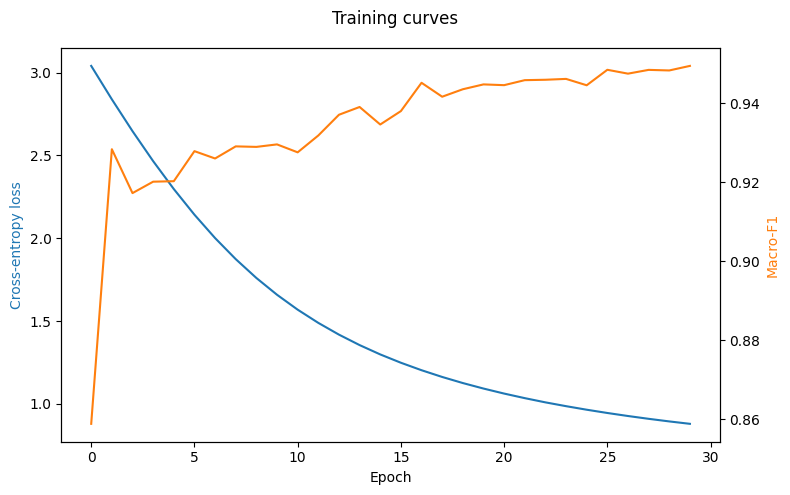

In [16]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(model.train_loss_history_, label="Train loss", color="tab:blue")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-entropy loss", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(model.val_metric_history_, label="Val macro-F1", color="tab:orange")
ax2.set_ylabel("Macro-F1", color="tab:orange")

fig.suptitle("Training curves")
fig.tight_layout()
plt.show()


## Step 10: Evaluate on the held-out test set


In [17]:
y_test_pred = model.predict(X_test)

report_df, test_macro_f1, test_acc = classification_report_custom(
    y_test, y_test_pred, n_classes, id2lang
)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro-F1: {test_macro_f1:.4f}")
report_df.sort_values("f1")


Test accuracy: 0.9426
Test macro-F1: 0.9412


,language,precision,recall,f1,support
4,gom_Deva,0.694444,0.50,0.581395,100
12,mar_Deva,0.696429,0.78,0.735849,100
6,hin_Deva,0.740458,0.97,0.839827,100
2,brx_Deva,0.962500,0.77,0.855556,100
3,doi_Deva,0.935484,0.87,0.901554,100
10,mai_Deva,0.909091,0.90,0.904523,100
17,san_Deva,0.932039,0.96,0.945813,100
9,khasi,0.917431,1.00,0.956938,100
14,npi_Deva,0.951456,0.98,0.965517,100
0,asm_Beng,1.000000,0.98,0.989899,100


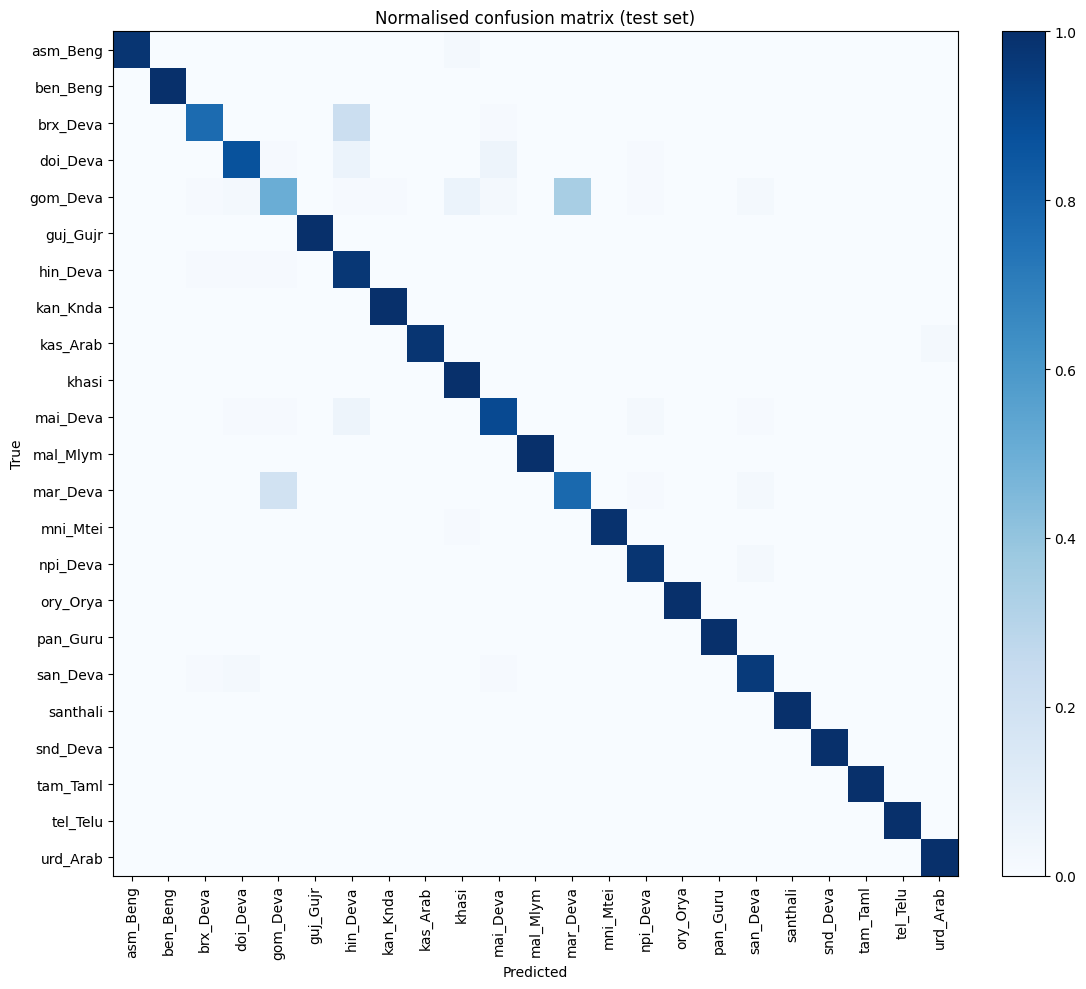

In [18]:
cm = confusion_matrix_custom(y_test, y_test_pred, n_classes)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, cmap="Blues")
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels([id2lang[i] for i in range(n_classes)], rotation=90)
ax.set_yticklabels([id2lang[i] for i in range(n_classes)])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Normalised confusion matrix (test set)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()


## Step 11: Save artifacts (vectorizer, model weights, report)


In [19]:
with open("model_weights.pkl", "wb") as f:
    pickle.dump({"W": model.W, "b": model.b, "lang2id": lang2id, "id2lang": id2lang}, f)

report_df.to_csv("test_classification_report.csv", index=False)
print("Saved: vectorizer.pkl, model_weights.pkl, test_classification_report.csv")


Saved: vectorizer.pkl, model_weights.pkl, test_classification_report.csv


## Step 12: Try it out — predict the language of a custom sentence


In [37]:
def predict_language(text, vectorizer, model, id2lang):
    X = vectorizer.transform([text])
    probs = model.predict_proba(X)[0]
    pred_id = int(np.argmax(probs))
    return id2lang[pred_id], probs[pred_id]

sample = "ખુબ ખુબ આભાર."
lang, conf = predict_language(sample, vectorizer, model, id2lang)
print(f"Predicted language: {lang} (confidence={conf:.3f})")


Predicted language: guj_Gujr (confidence=0.115)


## Notes

- **No `sklearn` classes** are used anywhere for feature extraction, modeling, or
  evaluation — `CustomTfidfVectorizer`, `SoftmaxLogisticRegression`, and all metric
  functions (`confusion_matrix_custom`, `precision_recall_f1_per_class`,
  `macro_f1_score`, `accuracy_score_custom`) are implemented from scratch with
  `numpy`/`scipy.sparse` only used as numerical containers.
- **Reproducibility**: a fixed `RANDOM_SEED` is used for sampling, splitting, weight
  initialization, and batch shuffling.
- **Scaling knobs**: if training is slow or memory-constrained, lower `max_features` in
  `CustomTfidfVectorizer`, increase `min_df`, or reduce `TARGET_PER_LANGUAGE`.
- **Data access**: if `get_dataset_config_names` or `load_dataset` raise an
  authentication error, run `huggingface-cli login` in a terminal (or set the
  `HF_TOKEN` environment variable) after accepting the dataset's terms of use on the
  Hugging Face Hub.
